# Heavy tails and survival analysis

How to model time-to-event data (lifetimes, failure times, durations) with the survival and hazard functions, why the Weibull shape parameter encodes three qualitatively different aging behaviors, the single most important wrinkle in survival data - censoring - and how ignoring it biases estimates, plus what a heavy tail (Pareto) means for risk when the mean may not even exist.


## Survival, hazard, and the structure of time-to-event data

For a nonnegative time $T$ with density $f$ and cdf $F$, define the survival function $S(t)=P(T>t)=1-F(t)$
and the hazard $h(t)=f(t)/S(t)$, the instantaneous event rate given survival to $t$. The cumulative
hazard is $H(t)=\int_0^t h(u)\,du$.

Theorem (the three are equivalent). $h(t)=-\dfrac{d}{dt}\log S(t)$, hence $S(t)=\exp(-H(t))$ and
$f(t)=h(t)\exp(-H(t))$. Any one of $f,S,h$ determines the others.

Proof. $\dfrac{d}{dt}\log S(t)=S'(t)/S(t)=-f(t)/S(t)=-h(t)$; integrate from $0$ with $S(0)=1$ to get
$\log S(t)=-H(t)$, and differentiate $F=1-S$ for $f$. $\quad\blacksquare$

The hazard's shape is the modeling content. The Weibull with shape $k$ has $h(t)\propto t^{k-1}$:
increasing for $k>1$ (aging, wear-out), decreasing for $k<1$ (infant mortality), constant for $k=1$
(the exponential).

Theorem (the exponential is memoryless, uniquely). $T$ has constant hazard if and only if
$P(T>s+t\mid T>s)=P(T>t)$ for all $s,t\ge 0$, which holds only for the exponential among continuous
distributions.

Proof. Constant hazard $h$ gives $S(t)=e^{-ht}$, and $S(s+t)/S(s)=e^{-ht}=S(t)$, which is the
memoryless identity. Conversely the identity says $S(s+t)=S(s)S(t)$; the only measurable solutions are
$S(t)=e^{-ht}$, the exponential. $\quad\blacksquare$

## Censoring and the censored likelihood

In real studies some subjects have not yet had the event when observation ends: their times are
right-censored. We observe $(\,y_i=\min(T_i,C_i),\ \delta_i=\mathbf 1\{T_i\le C_i\}\,)$.

Theorem (censored likelihood). Under independent censoring the likelihood is
$$L(\theta)=\prod_{i} f(y_i\mid\theta)^{\delta_i}\, S(y_i\mid\theta)^{1-\delta_i}.$$
An observed event contributes its density; a censored observation contributes only the information that
$T_i>y_i$, namely the survival probability. Discarding censored cases or treating them as events both
bias the estimate; the censored likelihood is the correct accounting, and the nonparametric Kaplan-Meier
estimator (in the applied section) is its model-free counterpart.

## Heavy tails: when moments and the CLT fail

Definition (heavy/regularly-varying tail). A distribution has a power-law tail of index $\alpha$ if
$P(X>x)\sim c\,x^{-\alpha}$ as $x\to\infty$. Then $\mathbb E[X^p]<\infty$ only for $p<\alpha$: the
variance is infinite for $\alpha\le 2$ and even the mean is infinite for $\alpha\le 1$. The Pareto and
the Cauchy ($\alpha=1$) are the standard examples.

Theorem (the classical CLT requires finite variance). The central limit theorem gives a Gaussian limit
for $\sqrt n(\bar X-\mu)$ only when $\mathrm{Var}(X)<\infty$. For $1<\alpha<2$ the sample mean still
converges to $\mu$ but its fluctuations are non-Gaussian and decay at the slower rate $n^{1/\alpha-1}$,
with an $\alpha$-stable limit. The sum is dominated by its largest term rather than by an accumulation of
many comparable terms.

Counterexample (the single big jump). For $\alpha<1$ (infinite mean) the ratio $\max_i X_i/\sum_i X_i$
does not vanish as $n\to\infty$: one observation always carries a non-negligible fraction of the total,
the running mean never settles, and ordinary standard errors are meaningless. For $1<\alpha<2$ the mean
is finite so the ratio does vanish, but only at the slow rate $n^{1/\alpha-1}$, far slower than the
$n^{-1}$ decay of a light tail, so self-averaging is sluggish and the central-limit rate degrades. We
contrast a light tail with an infinite-mean heavy tail below, and confirm the exponential's
memorylessness.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize as opt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import WeibullDistribution, ParetoDistribution, ExponentialDistribution
rng = np.random.RandomState(0)

## 1. Survival and hazard functions

For a positive lifetime $T$ with density $f$ and CDF $F$, survival analysis works with two derived functions: the survival function $S(t)=P(T>t)=1-F(t)$ (fraction still alive at $t$) and the hazard $h(t)=f(t)/S(t)$ (instantaneous failure rate given survival to $t$). The hazard is the heart of the field - it says how "risk of failure right now" changes with age.


## 2. The Weibull shape parameter is the aging story

The Weibull's shape $k$ determines the hazard's direction, capturing three regimes every reliability engineer knows:

- $k<1$: decreasing hazard - infant mortality (early failures, then survivors stabilize);
- $k=1$: constant hazard - memoryless (this is the exponential; failure is age-independent);
- $k>1$: increasing hazard - wear-out (aging, the longer you've lived the likelier you fail next).

We plot the three hazard shapes from Weibull distributions of differing shape.


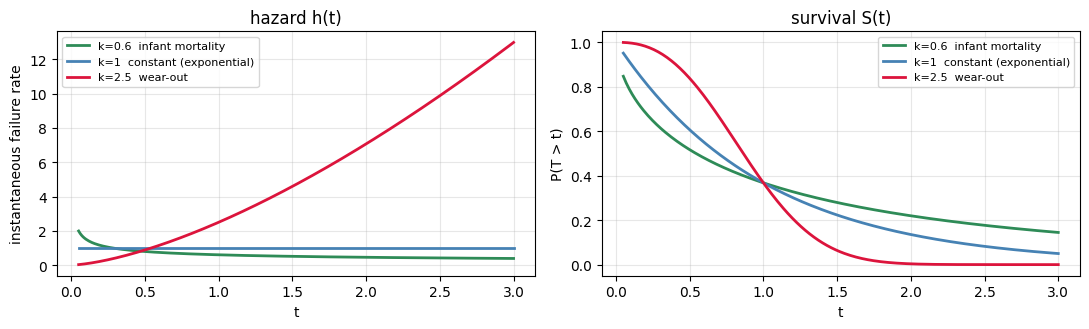

In [2]:
t = np.linspace(0.05, 3, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
# mixle's WeibullDistribution(shape, scale) is the same family; we use scipy here
# only for the closed-form survival/CDF so the hazard h = f / S is exact and clean
for k, c, lbl in [(0.6, 'seagreen', 'k=0.6  infant mortality'), (1.0, 'steelblue', 'k=1  constant (exponential)'),
                  (2.5, 'crimson', 'k=2.5  wear-out')]:
    f = stats.weibull_min.pdf(t, k, scale=1.0)
    S = stats.weibull_min.sf(t, k, scale=1.0)
    hazard = f / np.clip(S, 1e-9, None)
    ax[0].plot(t, hazard, color=c, lw=2, label=lbl)
    ax[1].plot(t, S, color=c, lw=2, label=lbl)
ax[0].set_title('hazard h(t)'); ax[0].set_xlabel('t'); ax[0].set_ylabel('instantaneous failure rate'); ax[0].legend(fontsize=8)
ax[1].set_title('survival S(t)'); ax[1].set_xlabel('t'); ax[1].set_ylabel('P(T > t)'); ax[1].legend(fontsize=8)
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Censoring: the defining problem of survival data

In real lifetime data the study ends (or a subject drops out) before every unit has failed: we observe only that $T > c$ for those units - right censoring. Throwing those observations away, or pretending the censoring time is the failure time, biases the estimated lifetime downward. The correct likelihood uses the density $f(t)$ for observed failures and the survival $S(c)$ for censored units:

$$\ell(\theta)=\sum_{\text{failed}}\log f(t_i\mid\theta) + \sum_{\text{censored}}\log S(c_i\mid\theta).$$

We simulate Weibull lifetimes, censor at a horizon, and compare three fits: naive (censored treated as failures), mixle on the fully observed data (the unattainable ideal), and the proper censored MLE.


In [3]:
true_k, true_scale = 1.8, 2.0
T_full = stats.weibull_min.rvs(true_k, scale=true_scale, size=2000, random_state=rng)
horizon = 2.5
observed = np.minimum(T_full, horizon)
is_failure = T_full <= horizon
print('%.0f%% of lifetimes are censored at the horizon' % (100 * (~is_failure).mean()))

# proper censored MLE for the Weibull (shape k, scale lam)
def neg_loglik(params):
    k, lam = params
    if k <= 0 or lam <= 0: return 1e12
    logf = stats.weibull_min.logpdf(observed[is_failure], k, scale=lam)
    logS = stats.weibull_min.logsf(observed[~is_failure], k, scale=lam)
    return -(logf.sum() + logS.sum())
cens = opt.minimize(neg_loglik, [1.0, 1.0], method='Nelder-Mead').x

naive_k, _, naive_lam = stats.weibull_min.fit(observed, floc=0)   # naive: censored counted as failures

print('true              : k=%.2f scale=%.2f' % (true_k, true_scale))
print('naive (ignore cens): k=%.2f scale=%.2f   <- biased: lifetimes look shorter' % (naive_k, naive_lam))
print('censored MLE       : k=%.2f scale=%.2f   <- recovers the truth' % (cens[0], cens[1]))

24% of lifetimes are censored at the horizon
true              : k=1.80 scale=2.00
naive (ignore cens): k=2.31 scale=1.81   <- biased: lifetimes look shorter
censored MLE       : k=1.75 scale=2.03   <- recovers the truth


## 4. Heavy tails: when the mean is a lie

A heavy-tailed distribution puts non-negligible probability on extreme values - the Pareto $P(X>x)\propto x^{-\alpha}$ is the archetype (wealth, city sizes, file sizes, insurance losses). Its danger: for $\alpha\le 1$ the mean is infinite, and for $\alpha\le 2$ the variance is infinite, so the sample mean is unstable and a "typical value" can be wildly misleading. We show the running sample mean of Pareto draws refusing to settle, next to a Gaussian's that converges immediately.


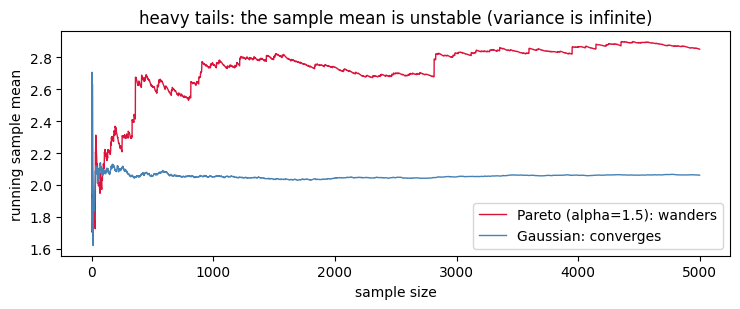

a single draw can dominate: max Pareto value = 198 x the median


In [4]:
alpha = 1.5                                          # mean exists (alpha>1) but variance does NOT (alpha<2)
pareto = np.asarray(ParetoDistribution(1.0, alpha).sampler(seed=3).sample(5000), float)
gauss = rng.normal(np.mean(pareto[:50]), 1.0, 5000)
run_mean = lambda x: np.cumsum(x) / np.arange(1, len(x) + 1)

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(run_mean(pareto), color='crimson', lw=1, label='Pareto (alpha=1.5): wanders')
ax.plot(run_mean(gauss), color='steelblue', lw=1, label='Gaussian: converges')
ax.set_xlabel('sample size'); ax.set_ylabel('running sample mean'); ax.legend(); ax.set_title('heavy tails: the sample mean is unstable (variance is infinite)')
plt.tight_layout(); plt.show()
print('a single draw can dominate: max Pareto value = %.0f x the median' % (pareto.max() / np.median(pareto)))

## The Kaplan-Meier check

Before trusting a parametric survival fit, compare it to the nonparametric Kaplan-Meier estimator, which makes no shape assumption and handles censoring directly: $\hat S(t)=\prod_{t_i\le t}(1-d_i/n_i)$ over event times $t_i$ with $d_i$ events and $n_i$ at risk. Agreement between KM and the fitted Weibull validates the parametric form; systematic deviation warns against it.


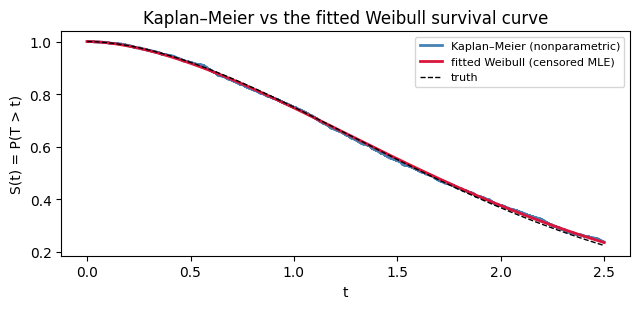

KM and the censored-MLE Weibull agree -> the parametric form is justified here.


In [5]:
def kaplan_meier(times, event):
    order = np.argsort(times); t, e = np.asarray(times)[order], np.asarray(event)[order]
    n = len(t); S = 1.0; xs, ys = [0.0], [1.0]
    for i in range(n):
        at_risk = n - i
        if e[i]:                                          # an observed event (not censored)
            S *= (1 - 1.0 / at_risk)
        xs.append(t[i]); ys.append(S)
    return np.array(xs), np.array(ys)

km_t, km_s = kaplan_meier(observed, is_failure)
grid = np.linspace(0, observed.max(), 200)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.step(km_t, km_s, where='post', color='steelblue', lw=2, label='Kaplan–Meier (nonparametric)')
ax.plot(grid, stats.weibull_min.sf(grid, cens[0], scale=cens[1]), color='crimson', lw=2, label='fitted Weibull (censored MLE)')
ax.plot(grid, stats.weibull_min.sf(grid, true_k, scale=true_scale), 'k--', lw=1, label='truth')
ax.set_xlabel('t'); ax.set_ylabel('S(t) = P(T > t)'); ax.legend(fontsize=8)
ax.set_title('Kaplan–Meier vs the fitted Weibull survival curve')
plt.tight_layout(); plt.show()
print('KM and the censored-MLE Weibull agree -> the parametric form is justified here.')

## Illustration: the single big jump, and memorylessness

We compare the max-to-sum ratio for a finite-variance distribution against a heavy-tailed Pareto with
infinite variance. For the heavy tail one observation keeps claiming a sizeable share of the total, so
the average is unstable and the central limit theorem does not apply. We also verify the exponential's
memoryless property numerically.

In [6]:
rng = np.random.RandomState(0)
def max_over_sum(sampler, n):
    x = sampler(n); return x.max() / x.sum()
light = lambda n: rng.exponential(1.0, n)                  # finite variance
heavy = lambda n: (1 - rng.random(n)) ** (-1 / 0.8)        # Pareto, alpha = 0.8 (infinite mean)
print('  n        max/sum  (light tail)     max/sum  (heavy tail, alpha=0.8)')
for n in [100, 10000, 1000000]:
    print('  %7d        %.4f                    %.4f' %
          (n, np.mean([max_over_sum(light, n) for _ in range(20)]),
           np.mean([max_over_sum(heavy, n) for _ in range(20)])))
print('light tail: max/sum -> 0 (the mean self-averages); infinite-mean heavy tail: it stays well above 0 (one big jump).')
# exponential memorylessness: P(T > s+t | T > s) = P(T > t)
T = rng.exponential(2.0, 2000000); s, t = 1.0, 1.5
cond = np.mean(T[T > s] > s + t); marg = np.mean(T > t)
print('exponential: P(T>s+t | T>s) = %.3f   P(T>t) = %.3f   (equal: memoryless)' % (cond, marg))

  n        max/sum  (light tail)     max/sum  (heavy tail, alpha=0.8)
      100        0.0525                    0.4561
    10000        0.0010                    0.3244


  1000000        0.0000                    0.2766
light tail: max/sum -> 0 (the mean self-averages); infinite-mean heavy tail: it stays well above 0 (one big jump).
exponential: P(T>s+t | T>s) = 0.472   P(T>t) = 0.473   (equal: memoryless)


## References

- Kaplan, E. L. & Meier, P. (1958). Nonparametric estimation from incomplete observations (https://doi.org/10.2307/2281868). JASA 53(282), 457-481.
- Cox, D. R. (1972). Regression models and life-tables (https://doi.org/10.1111/j.2517-6161.1972.tb00899.x). JRSS-B 34(2), 187-220. - proportional hazards.
- Klein, J. P. & Moeschberger, M. L. (2003). Survival Analysis: Techniques for Censored and Truncated Data, 2nd ed. Springer.
- Clauset, A., Shalizi, C. R. & Newman, M. E. J. (2009). Power-law distributions in empirical data (https://doi.org/10.1137/070710111). SIAM Review 51(4), 661-703.
- Embrechts, P., Klüppelberg, C. & Mikosch, T. (1997). Modelling Extremal Events. Springer. - extreme-value theory / GPD tails.


## Exercises and extensions

1. Kaplan-Meier vs parametric survival. Implement the nonparametric Kaplan-Meier estimator (with Greenwood variance) for right-censored data and overlay it on the fitted Weibull $S(t)$; quantify where the parametric assumption helps (extrapolation, small samples) and where KM is safer.
2. Proportional hazards. Simulate two groups with a hazard ratio and fit a Cox proportional-hazards model (partial likelihood, Cox 1972) to estimate it; check the proportional-hazards assumption with scaled-Schoenfeld residuals. Compare to fitting separate Weibulls per group.
3. Censoring-fraction bias study. Sweep the censoring horizon so 10-80% of observations are censored; plot the bias of the naive (ignore-censoring) fit vs the censored MLE for both Weibull parameters, and report the censoring level at which the naive estimate becomes unusable.
4. Tail-index estimation done properly. Implement the Hill estimator and the Clauset-Shalizi-Newman (2009) power-law fitting procedure (MLE for $x_{\min}$ and $\alpha$, plus a KS-based goodness-of-fit p-value) on a heavy-tailed dataset; decide whether a power law is even justified before reporting a mean. Optionally fit a generalized Pareto tail (EVT).
